In [35]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

df_school = pd.read_csv('student_exam_data.csv')  # Absolute/Relative path to the CSV file
df_school

# 1. Converted 'status' column text (Placed/Not Placed) into 1 and 0

,Roll_No,Study_Hours_Per_Day,Attendance_Percent,Stream,Result
0,101,7.8,88,Science,Pass
1,102,2.2,95,Science,Pass
2,103,6.8,76,Commerce,Pass
3,104,7.6,93,Science,Pass
4,105,5.7,75,Science,Pass
5,106,3.7,89,Commerce,Pass
6,107,3.5,74,Commerce,Pass
7,108,7.7,80,Science,Pass
8,109,3.3,83,Commerce,Fail
9,110,2.7,81,Science,Fail


In [36]:
df_school['Result'] = df_school['Result'].map({'Pass':1,'Fail':0})

In [37]:
# 1. Selecting input features (X) and target variable (y)
X = df_school[['Study_Hours_Per_Day', 'Attendance_Percent']] # This is the input feature set
y = df_school['Result'] # This is the target variable to be predicted

# 2. Splitting the data into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Training the Logistic Regression model
model_school = LogisticRegression()
model_school.fit(X_train, y_train)

# 4. Making predictions on the test set
y_pred = model_school.predict(X_test)

# 5. Evaluating the model accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"School Model Accuracy: {accuracy * 100:.2f}%")

School Model Accuracy: 66.67%


In [38]:
# Assuming a student studies 8.5 hours per day and has 90% school attendance
# Creating a DataFrame with the correct feature names to avoid any UserWarning
test_student = pd.DataFrame([[8.5, 90]], columns=['Study_Hours_Per_Day', 'Attendance_Percent'])

prediction = model_school.predict(test_student)

if prediction[0] == 1:
    print("Result Prediction: PASS! ")
else:
    print("Result Prediction: FAIL! ")

Result Prediction: PASS! 


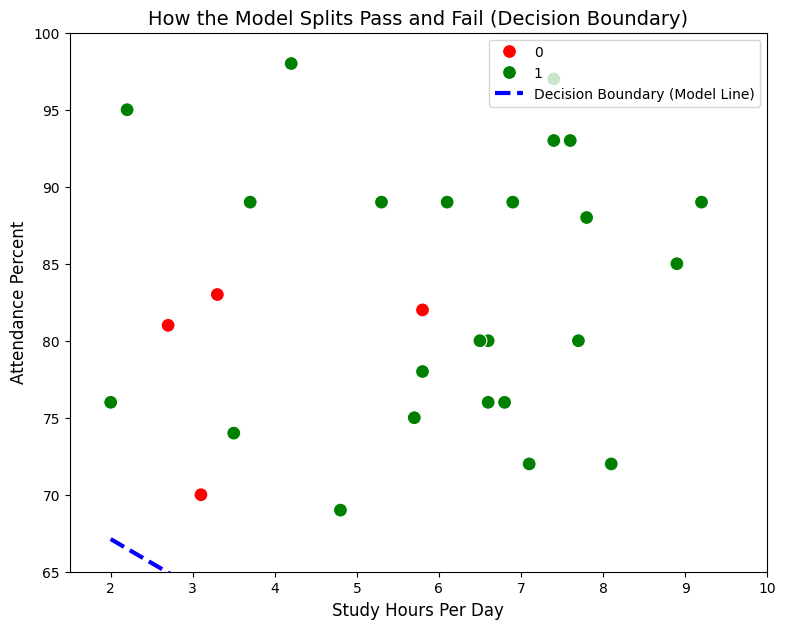

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Setting up the figure size
plt.figure(figsize=(9, 7))

# 2. Plotting the actual data points using a Scatter Plot
sns.scatterplot(
    x='Study_Hours_Per_Day', 
    y='Attendance_Percent', 
    hue='Result', 
    data=df_school, 
    palette={1: 'green', 0: 'red'}, 
    s=100, 
    zorder=5 # Keeps the data points layered on top of the boundary line
)

# 3. Calculating the Logistic Regression Decision Boundary line
# Formula: w0 + w1*x + w2*y = 0  =>  y = -(w0 + w1*x) / w2
b = model_school.intercept_[0]
w1, w2 = model_school.coef_[0]

# Defining the range for the X-axis (Study Hours from 2 to 10)
x_values = np.linspace(2, 10, 100)
# Computing the corresponding Y-axis (Attendance) values for the line
y_values = -(b + w1 * x_values) / w2

# 4. Drawing the Decision Boundary line (Dashed Blue Line)
plt.plot(x_values, y_values, label='Decision Boundary (Model Line)', color='blue', linewidth=3, linestyle='--')

# 5. Configuring graph limits, labels, and titles
plt.xlim(1.5, 10)
plt.ylim(65, 100)
plt.title('How the Model Splits Pass and Fail (Decision Boundary)', fontsize=14)
plt.xlabel('Study Hours Per Day', fontsize=12)
plt.ylabel('Attendance Percent', fontsize=12)
plt.legend(loc='upper right')

# 6. Displaying the final plot
plt.show()

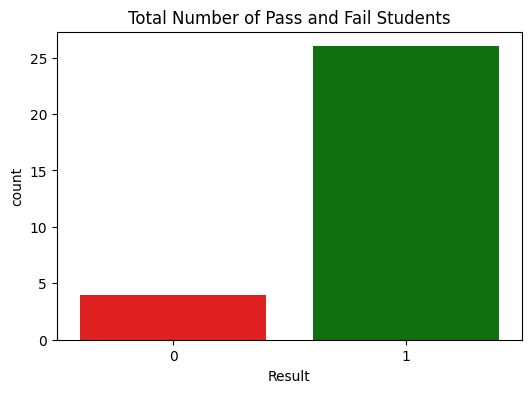

In [40]:
# To see the total number of pass (1) and fail (0) students
plt.figure(figsize=(6, 4))

# Updated with hue='Result' and legend=False to avoid deprecation warnings
sns.countplot(x='Result', hue='Result', data=df_school, palette={1: 'green', 0: 'red'}, legend=False)

plt.title('Total Number of Pass and Fail Students')
plt.show()